# Bedload transport: fitting and model comparison

Every number quoted in Section 5 of the manuscript and in Texts S5–S6, together
with Tables S1–S2 and Figure 2, is produced by this notebook from `data.csv`.

`data.csv` holds 239 points digitized from the published $Q_*$–$\Theta$ plot of
Cheng (2020): `Gamma` is the Shields stress $\Theta$, `Q` is the dimensionless
transport rate $Q_*$, and `Sources` names the original study.

Fits are performed on $\ln Q_*$, so residuals are multiplicative and all eleven
decades of $Q_*$ carry equal weight. RMSE values are therefore in natural-log
units; `exp(RMSE)` converts them to a multiplicative factor.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter, FixedLocator, FixedFormatter
from scipy.optimize import curve_fit

RNG = np.random.default_rng(0)          # seeded: the notebook is reproducible
THETA_C_LOC = 2.0 / 3.0                 # single-grain instantaneous threshold (Bagnold balance)

df = pd.read_csv("data.csv")
T, Q, SRC = df["Gamma"].values, df["Q"].values, df["Sources"].values
y, x = np.log(Q), np.log(T)
n = len(y)
out = {"n": int(n), "theta_min": float(T.min()), "theta_max": float(T.max())}


def gof(resid, k):
    # R^2, RMSE and AIC in log space. Dropped constants cancel in Delta-AIC.
    sse = float(np.sum(resid ** 2))
    return dict(R2=1 - sse / np.sum((y - y.mean()) ** 2),
                RMSE=float(np.sqrt(sse / n)),
                AIC=float(n * np.log(sse / n) + 2 * k), k=k)


print("n = %d,  Theta in [%.4f, %.2f],  Q* in [%.2e, %.2e]"
      % (n, T.min(), T.max(), Q.min(), Q.max()))

n = 239,  Theta in [0.0137, 8.49],  Q* in [2.36e-09, 2.85e+02]


## 1. Near-threshold asymptote

$\ln Q_* = \ln A_f + \tfrac{3}{2}\ln\Theta - \gamma/\Theta$, fitted to all 239
points. This is the relation quoted in the main text. Two free parameters, so
`curve_fit` returns a usable covariance and hence standard errors.

In [2]:
def asym(lnT, lnAf, gam):
    return lnAf + 1.5 * lnT - gam / np.exp(lnT)


p_as, c_as = curve_fit(asym, x, y, p0=[2.0, 0.3])
se_as = np.sqrt(np.diag(c_as))
out["asymptote"] = dict(A_f=float(np.exp(p_as[0])),
                        A_f_lo=float(np.exp(p_as[0] - se_as[0])),
                        A_f_hi=float(np.exp(p_as[0] + se_as[0])),
                        gamma=float(p_as[1]), gamma_se=float(se_as[1]),
                        sigma0_implied=float(THETA_C_LOC / p_as[1]),
                        **gof(y - asym(x, *p_as), 2))
a = out["asymptote"]
print("A_f    = %.2f  (%.2f - %.2f)      [ln A_f = %.3f]" % (a["A_f"], a["A_f_lo"], a["A_f_hi"], np.log(a["A_f"])))
print("gamma  = %.4f +/- %.4f" % (a["gamma"], a["gamma_se"]))
print("sigma_0 = Theta_c^loc/gamma = %.2f" % a["sigma0_implied"])
print("R2 = %.4f   RMSE = %.3f" % (a["R2"], a["RMSE"]))

A_f    = 13.73  (11.82 - 15.95)      [ln A_f = 2.620]
gamma  = 0.2717 +/- 0.0063
sigma_0 = Theta_c^loc/gamma = 2.45
R2 = 0.9490   RMSE = 1.658


## 2. Stage one — transport capacity from the unsuppressed regime

Far above threshold the active fraction is close to unity and varies slowly, so
the $\Theta>1$ subset constrains the capacity almost independently of the
threshold statistics. Leaving the exponent free **tests** the value predicted by
the turbulence budget instead of imposing it.

In [3]:
out["high_theta"] = {}
for cut in (0.5, 1.0, 2.0):
    m = T > cut
    slope, inter = np.polyfit(x[m], y[m], 1)
    out["high_theta"]["cut_%g" % cut] = dict(
        n=int(m.sum()),
        A_fixed_exponent=float(np.exp(np.mean(y[m] - 1.5 * x[m]))),
        free_exponent=float(slope), A_free=float(np.exp(inter)))
    print("Theta > %-4g  n=%3d   free exponent = %.2f   A (exponent held at 3/2) = %5.2f"
          % (cut, m.sum(), slope, out["high_theta"]["cut_%g" % cut]["A_fixed_exponent"]))

A_CAP = out["high_theta"]["cut_1"]["A_fixed_exponent"]
print("\ncapacity used in stage two: A = %.2f" % A_CAP)

Theta > 0.5   n= 75   free exponent = 1.55   A (exponent held at 3/2) = 11.61
Theta > 1     n= 51   free exponent = 1.50   A (exponent held at 3/2) = 11.91
Theta > 2     n= 33   free exponent = 1.55   A (exponent held at 3/2) = 11.93

capacity used in stage two: A = 11.91


Stage one fits an *unsuppressed* power law over a range where the model still
predicts some residual suppression, so $A$ should sit below $A_f$ by the mean of
$\exp(-\gamma/\Theta)$ over that subset. The offset is therefore predicted, not
independent evidence; what is informative is how closely the prediction is met.

In [4]:
hi = T > 1
out["capacity_bias"] = dict(
    mean_suppression=float(np.exp(np.mean(-p_as[1] / T[hi]))),
    observed_ratio=float(A_CAP / np.exp(p_as[0])),
    theta_geomean=float(np.exp(np.mean(np.log(T[hi])))))
cb = out["capacity_bias"]
print("model predicts A/A_f = %.3f over Theta>1 (geometric-mean Theta = %.2f)"
      % (cb["mean_suppression"], cb["theta_geomean"]))
print("observed            A/A_f = %.3f     -> agreement to %.1f%%"
      % (cb["observed_ratio"], 100 * (1 - cb["observed_ratio"] / cb["mean_suppression"])))

model predicts A/A_f = 0.888 over Theta>1 (geometric-mean Theta = 2.74)
observed            A/A_f = 0.867     -> agreement to 2.4%


## 3. Stage two — the full extreme-value closure

$Q_* = A\,\Theta^{3/2}\,P(M_T > \Theta_c^{\rm loc})$ with GEV block maxima whose
location and scale are proportional to the mean Shields stress,
$\mu_\Gamma=\mu_0\Theta$ and $\sigma_\Gamma=\sigma_0\Theta$.

Two controls matter here. With **both** the amplitude and the location free the
fit runs away, because the data never reach the saturation regime that would fix
$\mu_0$. Fixing the capacity removes that degeneracy — and it does so with the
shape held at zero, which shows the degeneracy is removed by supplying the
capacity externally, not by freeing $\xi$.

In [5]:
def gev_P(T_, mu0, s0, xi):
    # P(M_T > Theta_c^loc). The z <= 0 branch is below the support: P = 1.
    if abs(xi) < 1e-9:
        return -np.expm1(-np.exp(-((THETA_C_LOC / T_) - mu0) / s0))
    z = np.clip(1.0 + xi * ((THETA_C_LOC / T_) - mu0) / s0, 1e-12, None)
    return -np.expm1(-z ** (-1.0 / xi))


def gev_at(T_, A_, mu0, s0, xi):
    return np.log(A_) + 1.5 * np.log(T_) + np.log(np.clip(gev_P(T_, mu0, s0, xi), 1e-300, None))


def gev(T_, mu0, s0, xi):
    return gev_at(T_, A_CAP, mu0, s0, xi)


def fit_gev(Tv, yv, A_, p0=(7.2, 0.7, 0.14)):
    try:
        p, _ = curve_fit(lambda tt, m, ss, xx: gev_at(tt, A_, m, ss, xx),
                         Tv, yv, p0=list(p0), maxfev=200000)
        return p
    except Exception:
        return None


p_gev = fit_gev(T, y, A_CAP)

# control A: amplitude AND location free -> runaway
def gum_full(T_, lnA, mu0, s0):
    return lnA + 1.5 * np.log(T_) + np.log(np.clip(
        -np.expm1(-np.exp(-((THETA_C_LOC / T_) - mu0) / s0)), 1e-300, None))


p_gf, _ = curve_fit(gum_full, T, y, p0=[2.5, 3.0, 1.0], maxfev=200000)
out["gumbel_full_runaway"] = dict(A=float(np.exp(p_gf[0])), mu0=float(p_gf[1]),
                                  sigma0=float(p_gf[2]), **gof(y - gum_full(T, *p_gf), 3))

# control B: xi = 0 but capacity fixed -> identifiable
p_ctl, _ = curve_fit(lambda tt, m, ss: gev(tt, m, ss, 0.0), T, y, p0=[1.0, 2.0], maxfev=200000)
out["gumbel_capacity_fixed"] = dict(mu0=float(p_ctl[0]), sigma0=float(p_ctl[1]),
                                    **gof(y - gev(T, p_ctl[0], p_ctl[1], 0.0), 3))

print("control A  xi=0, amplitude free : A -> %.3g, mu_0 -> %.1f   (runaway)"
      % (out["gumbel_full_runaway"]["A"], out["gumbel_full_runaway"]["mu0"]))
print("control B  xi=0, capacity fixed : mu_0 = %.2f, sigma_0 = %.2f, R2 = %.4f   (identifiable)"
      % (out["gumbel_capacity_fixed"]["mu0"], out["gumbel_capacity_fixed"]["sigma0"],
         out["gumbel_capacity_fixed"]["R2"]))

control A  xi=0, amplitude free : A -> 2.87e+12, mu_0 -> -64.0   (runaway)
control B  xi=0, capacity fixed : mu_0 = 1.06, sigma_0 = 2.38, R2 = 0.9477   (identifiable)


The bootstrap re-estimates **both** stages inside each resample, so the reported
intervals are not conditional on the full-sample capacity, and each fit is
started from a randomised point so the resamples are not pulled toward the
point estimate.

In [6]:
boot = []
for _ in range(400):
    i = RNG.integers(0, n, n)
    Ti, yi, xi_ = T[i], y[i], x[i]
    m = Ti > 1
    if m.sum() < 15:
        continue
    A_b = np.exp(np.mean(yi[m] - 1.5 * xi_[m]))          # stage one, re-estimated
    p = fit_gev(Ti, yi, A_b, tuple(p_gev * RNG.uniform(0.7, 1.4, 3)))
    if p is not None and 0.01 < p[1] < 50 and -1 < p[2] < 1.5:
        boot.append(p)
boot = np.array(boot)
ci = lambda j: [float(v) for v in np.percentile(boot[:, j], [2.5, 50, 97.5])]
out["gev"] = dict(A_capacity_fixed=float(A_CAP), mu0=float(p_gev[0]),
                  sigma0=float(p_gev[1]), xi=float(p_gev[2]),
                  mu0_ci=ci(0), sigma0_ci=ci(1), xi_ci=ci(2),
                  frac_xi_positive=float(np.mean(boot[:, 2] > 0)),
                  n_boot=int(len(boot)),
                  **gof(y - gev(T, *p_gev), 4))          # k=4: capacity counted
g = out["gev"]
for lab, key, val in (("mu_0", "mu0_ci", g["mu0"]), ("sigma_0", "sigma0_ci", g["sigma0"]),
                      ("xi", "xi_ci", g["xi"])):
    lo, med, hi_ = g[key]
    print("%-8s = %6.3f    95%% CI [%.3f, %.3f]" % (lab, val, lo, hi_))
print("\nresamples with xi > 0 : %.0f%% of %d" % (100 * g["frac_xi_positive"], g["n_boot"]))
print("R2 = %.4f   dAIC vs the asymptote = %+.1f" % (g["R2"], g["AIC"] - a["AIC"]))

mu_0     =  7.224    95% CI [5.468, 8.508]
sigma_0  =  0.709    95% CI [0.492, 1.118]
xi       =  0.140    95% CI [0.086, 0.188]

resamples with xi > 0 : 100% of 400
R2 = 0.9619   dAIC vs the asymptote = -66.0


For $\xi>0$ the fitted distribution has a finite lower endpoint. When that
endpoint falls inside the measured range the predicted curve acquires a corner,
which is an artefact of the parameterisation rather than a physical prediction.
`XI_SMOOTH` is therefore **computed**, not assumed: it is the largest shape on
the search grid for which the support boundary stays clear of the data. Figure 2
uses it; Text S6 reports the unconstrained value.

In [7]:
def _zmin(xi_):
    try:
        q, _ = curve_fit(lambda tt, m, ss: gev(tt, m, ss, xi_), T, y,
                         p0=[p_gev[0], p_gev[1]], maxfev=200000)
        return float(np.min(1 + xi_ * ((THETA_C_LOC / T) - q[0]) / q[1]))
    except Exception:
        return np.nan


grid = np.arange(0.05, 0.30, 0.002)
XI_BIND = float(next((xx for xx in grid if not np.isnan(_zmin(xx)) and _zmin(xx) <= 0), np.nan))
XI_SMOOTH = float(next((xx for xx in grid[::-1]
                        if not np.isnan(_zmin(xx)) and _zmin(xx) >= 0.40), 0.05))
p_sm, _ = curve_fit(gev, T, y, p0=[7.0, 0.8, 0.05], maxfev=300000,
                    bounds=([-50, 0.05, 0.0], [60, 20, XI_SMOOTH]))
zmin = float(np.min(1 + p_sm[2] * ((THETA_C_LOC / T) - p_sm[0]) / p_sm[1]))
out["gev_smooth"] = dict(xi_binding=XI_BIND, mu0=float(p_sm[0]), sigma0=float(p_sm[1]),
                         xi=float(p_sm[2]), min_support_z=zmin, **gof(y - gev(T, *p_sm), 3))
sm = out["gev_smooth"]
print("endpoint first enters the data range at xi = %.3f" % XI_BIND)
print("constrained fit used in Figure 2: xi = %.3f, mu_0 = %.2f, sigma_0 = %.3f"
      % (sm["xi"], sm["mu0"], sm["sigma0"]))
print("support margin min(z) = %+.3f    dAIC vs the unconstrained fit = %+.1f"
      % (sm["min_support_z"], sm["AIC"] - g["AIC"]))

endpoint first enters the data range at xi = 0.124
constrained fit used in Figure 2: xi = 0.102, mu_0 = 5.87, sigma_0 = 0.988
support margin min(z) = +0.402    dAIC vs the unconstrained fit = +0.8


## 4. Competing transport laws

Each competing model is fitted by the same criterion used to score it.
Meyer–Peter–Müller needs care: it predicts identically zero transport for
$\Theta\le\Theta_c$, so it cannot be scored below its own threshold and would
otherwise be charged for points it is not defined at. Its threshold is chosen on
a grid **subject to covering every measurement**, which is the fair comparison;
because that value then sits on the coverage constraint it is not counted as a
free parameter.

In [8]:
models = {}
Apow = np.exp(np.mean(y - 1.5 * x))
models["power_fixed_1.5"] = (np.log(Apow) + 1.5 * x, 1, dict(A=float(Apow)))
pf = np.polyfit(x, y, 1)
models["power_free"] = (np.polyval(pf, x), 2, dict(exponent=float(pf[0]), A=float(np.exp(pf[1]))))


def mpm(T_, A, Tc):
    return np.log(A) + 1.5 * np.log(np.clip(T_ - Tc, 1e-12, None))


best = None
for Tc in np.linspace(0.0, T.min() * 0.999, 400):
    lnA = np.mean(y - 1.5 * np.log(T - Tc))
    sse = np.sum((y - lnA - 1.5 * np.log(T - Tc)) ** 2)
    if best is None or sse < best[0]:
        best = (sse, Tc, np.exp(lnA))
_, Tc_mpm, A_mpm = best
p_mpm = np.array([A_mpm, Tc_mpm])
conv = {("%.3f" % tc): int((T <= tc).sum()) for tc in (0.03, 0.047, 0.06)}
models["MPM"] = (mpm(T, *p_mpm), 1, dict(A=float(A_mpm), Theta_c=float(Tc_mpm),
                                         n_representable=int(n),
                                         excluded_if_conventional_Tc=conv))

out["competing"] = {k: dict(gof(y - pred, kk), **extra) for k, (pred, kk, extra) in models.items()}
out["competing"]["asymptote"] = {j: a[j] for j in ("R2", "RMSE", "AIC", "k")}
out["competing"]["gev"] = {j: g[j] for j in ("R2", "RMSE", "AIC", "k")}
amin = min(v["AIC"] for v in out["competing"].values())
for v in out["competing"].values():
    v["dAIC"] = v["AIC"] - amin

print("%-20s %2s %8s %7s %8s" % ("model", "k", "R2", "RMSE", "dAIC"))
for k, v in sorted(out["competing"].items(), key=lambda kv: kv[1]["dAIC"]):
    print("%-20s %2d %8.4f %7.3f %8.1f" % (k, v["k"], v["R2"], v["RMSE"], v["dAIC"]))

M = out["competing"]["MPM"]
print("\nbest full-coverage MPM: A = %.2f, Theta_c = %.4f (below min Theta = %.4f)"
      % (M["A"], M["Theta_c"], T.min()))
print("a conventionally-thresholded MPM must discard: "
      + ", ".join("Theta_c=%s -> %d" % (kk, vv) for kk, vv in sorted(M["excluded_if_conventional_Tc"].items())))
print("dAIC of MPM relative to the asymptote: %+.0f"
      % (M["dAIC"] - out["competing"]["asymptote"]["dAIC"]))

model                 k       R2    RMSE     dAIC
gev                   4   0.9619   1.432      0.0
asymptote             2   0.9490   1.658     66.0
power_free            2   0.8498   2.843    324.0
MPM                   1   0.6438   4.379    528.4
power_fixed_1.5       1   0.5479   4.933    585.4

best full-coverage MPM: A = 0.26, Theta_c = 0.0137 (below min Theta = 0.0137)
a conventionally-thresholded MPM must discard: Theta_c=0.030 -> 45, Theta_c=0.047 -> 89, Theta_c=0.060 -> 104
dAIC of MPM relative to the asymptote: +462


The full-range ranking is not a verdict on Meyer–Peter–Müller inside its own
domain of validity. Restricted to $\Theta>0.06$, where every candidate applies,
each model is **refitted there** so the forms are compared at their best.

In [9]:
common = T > 0.06
Tc_, yc_, xc_ = T[common], y[common], x[common]
sst = np.sum((yc_ - yc_.mean()) ** 2)
out["common_domain"] = {"theta_min": 0.06, "n": int(common.sum())}


def score_common(resid, extra=None):
    d = dict(R2=float(1 - np.sum(resid ** 2) / sst), RMSE=float(np.sqrt(np.mean(resid ** 2))))
    if extra:
        d.update(extra)
    return d


pa_c, _ = curve_fit(asym, xc_, yc_, p0=[2.0, 0.3])
out["common_domain"]["asymptote"] = score_common(yc_ - asym(xc_, *pa_c))
pm_c, _ = curve_fit(mpm, Tc_, yc_, p0=[10.0, 0.03], maxfev=50000)
out["common_domain"]["MPM"] = score_common(yc_ - mpm(Tc_, *pm_c),
                                           dict(A=float(pm_c[0]), Theta_c=float(pm_c[1])))
pf_c = np.polyfit(xc_, yc_, 1)
out["common_domain"]["power_free"] = score_common(yc_ - np.polyval(pf_c, xc_),
                                                  dict(exponent=float(pf_c[0])))
Ap_c = np.exp(np.mean(yc_ - 1.5 * xc_))
out["common_domain"]["power_fixed_1.5"] = score_common(yc_ - np.log(Ap_c) - 1.5 * xc_)

print("head-to-head on Theta > 0.06 (n = %d), each model refitted there" % common.sum())
for k in ("asymptote", "MPM", "power_free", "power_fixed_1.5"):
    v = out["common_domain"][k]
    print("   %-18s R2 = %.4f   RMSE = %.3f" % (k, v["R2"], v["RMSE"]))

head-to-head on Theta > 0.06 (n = 135), each model refitted there
   asymptote          R2 = 0.9888   RMSE = 0.307
   MPM                R2 = 0.9829   RMSE = 0.379
   power_free         R2 = 0.9620   RMSE = 0.565
   power_fixed_1.5    R2 = 0.8944   RMSE = 0.942


## 5. Residual diagnostics

Scatter is strongly regime dependent. Near threshold it exceeds the disagreement
between the model and any individual data set, which is a property of the
regime — transport there is controlled by rare events — rather than a defect of
the closure.

In [10]:
bands = [(0, 0.03), (0.03, 0.06), (0.06, 0.2), (0.2, 1), (1, 100)]
out["residuals"] = {}
for lab, pred in (("asymptote", asym(x, *p_as)), ("gev", gev(T, *p_gev))):
    r = y - pred
    out["residuals"][lab] = [dict(lo=lo, hi=hi_, n=int(((T >= lo) & (T < hi_)).sum()),
                                  bias=float(r[(T >= lo) & (T < hi_)].mean()),
                                  rmse=float(np.sqrt(np.mean(r[(T >= lo) & (T < hi_)] ** 2))))
                             for lo, hi_ in bands]
out["by_source"] = [dict(source=str(s), n=int((SRC == s).sum()),
                         theta_lo=float(T[SRC == s].min()), theta_hi=float(T[SRC == s].max()),
                         rmse=float(np.sqrt(np.mean((y - asym(x, *p_as))[SRC == s] ** 2))))
                    for s in np.unique(SRC)]

print("by Shields-stress band          asymptote        full GEV")
for ra, rg in zip(out["residuals"]["asymptote"], out["residuals"]["gev"]):
    print("  %.3g-%-5.3g n=%3d   bias %+5.2f rmse %.2f   bias %+5.2f rmse %.2f"
          % (ra["lo"], ra["hi"], ra["n"], ra["bias"], ra["rmse"], rg["bias"], rg["rmse"]))
print("\nby source (asymptote)")
for s in out["by_source"]:
    print("  %-22s n=%3d  Theta %.3f-%.2f  RMSE %.2f"
          % (s["source"], s["n"], s["theta_lo"], s["theta_hi"], s["rmse"]))

by Shields-stress band          asymptote        full GEV
  0-0.03  n= 45   bias +0.04 rmse 2.64   bias +0.00 rmse 2.10
  0.03-0.06  n= 59   bias -0.66 rmse 2.25   bias +0.04 rmse 2.00
  0.06-0.2   n= 29   bias +0.94 rmse 1.04   bias -0.62 rmse 1.15
  0.2-1     n= 55   bias +0.20 rmse 0.44   bias -0.29 rmse 0.54
  1-100   n= 51   bias -0.02 rmse 0.15   bias -0.00 rmse 0.12

by source (asymptote)
  Gilbert 1914           n= 59  Theta 0.062-0.86  RMSE 0.61
  Paintal 1971           n= 80  Theta 0.014-0.07  RMSE 2.44
  Taylor & Vanoni 1972   n= 20  Theta 0.023-0.04  RMSE 2.46
  Williams 1970          n= 23  Theta 0.045-0.65  RMSE 1.20
  Wilson 1996            n= 57  Theta 0.582-8.49  RMSE 0.25


## 6. Figure 2

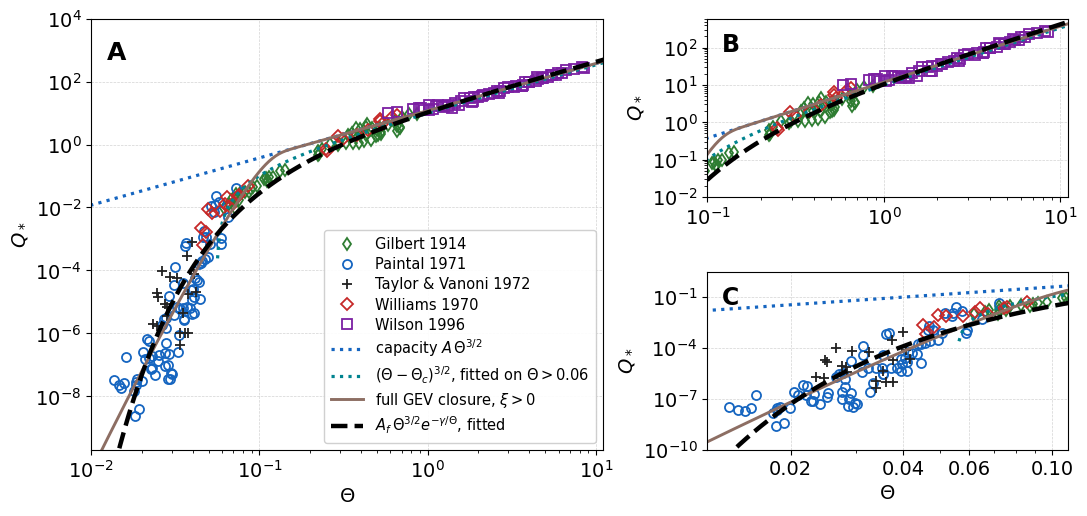

In [11]:
Tg = np.logspace(-2.2, 1.05, 500)
cap = A_CAP * Tg ** 1.5
gevc = np.exp(gev(Tg, *p_sm))                      # constrained shape: no artificial corner
asc = np.exp(asym(np.log(Tg), *p_as))
mpmc = np.where(Tg > pm_c[1], pm_c[0] * np.clip(Tg - pm_c[1], 1e-12, None) ** 1.5, np.nan)

plt.rcParams.update({"font.size": 14})
fig = plt.figure(figsize=(12.6, 5.6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.42, 1], hspace=0.42, wspace=0.24)
axA = fig.add_subplot(gs[:, 0]); axB = fig.add_subplot(gs[0, 1]); axC = fig.add_subplot(gs[1, 1])

marks = ["d", "o", "+", "D", "s"]
cols = ["#2e7d32", "#1565c0", "#212121", "#c62828", "#7b1fa2"]
for ax in (axA, axB, axC):
    for i, s in enumerate(np.unique(SRC)):
        m = SRC == s
        ax.loglog(T[m], Q[m], marks[i % 5], mfc="none", ms=6.5, mew=1.3,
                  color=cols[i % 5], ls="none", label=s if ax is axA else None)
    ax.loglog(Tg, cap, ":", color="#1565c0", lw=2.3,
              label=r"capacity $A\,\Theta^{3/2}$" if ax is axA else None)
    ax.loglog(Tg, mpmc, ":", color="#00838f", lw=2.3,
              label=r"$(\Theta-\Theta_c)^{3/2}$, fitted on $\Theta>0.06$" if ax is axA else None)
    ax.loglog(Tg, gevc, "-", color="#8d6e63", lw=2.1,
              label=r"full GEV closure, $\xi>0$" if ax is axA else None)
    ax.loglog(Tg, asc, "--", color="#000000", lw=3.2,
              label=r"$A_f\,\Theta^{3/2}e^{-\gamma/\Theta}$, fitted" if ax is axA else None)
    ax.grid(True, which="major", ls="--", lw=0.5, alpha=0.55)

axA.set_xlim(1e-2, 1.1e1); axA.set_ylim(2e-10, 1e4)
axA.set_xlabel(r"$\Theta$"); axA.set_ylabel(r"$Q_*$")
axA.legend(frameon=True, fontsize=10.5, ncol=1, loc="lower right", borderaxespad=0.5,
           handlelength=2.2, labelspacing=0.35, framealpha=0.92, borderpad=0.45)
axA.text(0.03, 0.95, "A", transform=axA.transAxes, fontsize=18, fontweight="bold", va="top")
axB.set_xlim(1e-1, 1.1e1); axB.set_ylim(1e-2, 6e2)
axB.text(0.04, 0.92, "B", transform=axB.transAxes, fontsize=17, fontweight="bold", va="top")
axC.set_xlim(1.2e-2, 1.1e-1); axC.set_ylim(1e-10, 3e0)
axC.xaxis.set_minor_formatter(NullFormatter())
axC.xaxis.set_major_locator(FixedLocator([0.02, 0.04, 0.06, 0.10]))
axC.xaxis.set_major_formatter(FixedFormatter(["0.02", "0.04", "0.06", "0.10"]))
axC.set_xlabel(r"$\Theta$")
axC.text(0.04, 0.92, "C", transform=axC.transAxes, fontsize=17, fontweight="bold", va="top")
for ax in (axB, axC):
    ax.set_ylabel(r"$Q_*$")

fig.savefig("fig2.pdf", bbox_inches="tight")
fig.savefig("fig2.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. Write every number to disk

`fit_results.json` is what the manuscript quotes from, so the text can be
checked against this file rather than against a transcription.

In [12]:
with open("fit_results.json", "w") as fh:
    json.dump(out, fh, indent=2)

print("wrote fit_results.json, fig2.pdf, fig2.png")
print("\nvalues quoted in the manuscript")
print("  A_f = %.1f (%.1f-%.1f),  gamma = %.3f +/- %.3f,  R2 = %.3f"
      % (a["A_f"], a["A_f_lo"], a["A_f_hi"], a["gamma"], a["gamma_se"], a["R2"]))
print("  free exponent on Theta>1 = %.2f,  capacity A = %.1f"
      % (out["high_theta"]["cut_1"]["free_exponent"], A_CAP))
print("  xi = %.3f, 95%% CI [%.3f, %.3f], %.0f%% of resamples positive"
      % (g["xi"], g["xi_ci"][0], g["xi_ci"][2], 100 * g["frac_xi_positive"]))
print("  dAIC: free power law %+.0f, MPM %+.0f, unsuppressed %+.0f, full GEV %+.0f"
      % (out["competing"]["power_free"]["dAIC"] - out["competing"]["asymptote"]["dAIC"],
         out["competing"]["MPM"]["dAIC"] - out["competing"]["asymptote"]["dAIC"],
         out["competing"]["power_fixed_1.5"]["dAIC"] - out["competing"]["asymptote"]["dAIC"],
         out["competing"]["gev"]["dAIC"] - out["competing"]["asymptote"]["dAIC"]))

wrote fit_results.json, fig2.pdf, fig2.png

values quoted in the manuscript
  A_f = 13.7 (11.8-15.9),  gamma = 0.272 +/- 0.006,  R2 = 0.949
  free exponent on Theta>1 = 1.50,  capacity A = 11.9
  xi = 0.140, 95% CI [0.086, 0.188], 100% of resamples positive
  dAIC: free power law +258, MPM +462, unsuppressed +519, full GEV -66
